# Agitation prediction: Feature extraction

**Author:** Eva Rombouts  
**Date:** 2024-07-19  
**Version:** 1.0

### Description
This script performs text preprocessing, topic modeling, and word embedding training on a dataset of care reports. It produces three output files: agitation_train, agitation_valid, and agitation_test, each containing extracted features. These features are prepared for subsequent modeling to predict agitation based on the text data.

In [1]:
!pip install GenCareAI
from GenCareAI.GenCareAIUtils import GenCareAISetup

setup = GenCareAISetup()

if setup.environment == 'Colab':
        !pip install -q pyLDAvis
        !python -m spacy download nl_core_news_sm -q


In [2]:
# Libraries for data manipulation 
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
tqdm.pandas()

# Visualisation libraries
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# NLP & Machine Learning libraries
import spacy
import gensim
from gensim import corpora
from gensim.models import Word2Vec

# Dutch SpaCy model
nlp = spacy.load('nl_core_news_sm', disable=['parser', 'tagger', 'ner'])

In [3]:
sample_size = 1000
seed = 6

# Load and sample data
df = pd.read_csv(setup.get_file_path('data/df_agitation.csv'))
# df = df.sample(sample_size, random_state=seed)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43108 entries, 0 to 43107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    43108 non-null  object
 1   label   43108 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 673.7+ KB


In [4]:
df['label'].value_counts()

label
0    38109
1     4999
Name: count, dtype: int64

## Text preprocessing

In [5]:
# Function for text preprocessing: lowercasing, tokenization, lemmatization, stop word removal, and word selection based on part-of-speech
def preprocess_text(text, nlp_model):
    doc = nlp_model(text)
    cleaned_tokens = [token.lemma_.lower() for token in doc if token.is_alpha and not token.is_stop and token.pos_ in ['VERB', 'NOUN', 'ADJ', 'ADV', 'INTJ']]
    return " ".join(cleaned_tokens)

# Apply preprocessing to the dataframe
df['text_clean'] = df['text'].progress_apply(lambda x: preprocess_text(x, nlp))

100%|██████████| 43108/43108 [01:49<00:00, 393.86it/s]


In [10]:
test_row = 5
print(df['text'].iloc[test_row])
print(df['text_clean'].iloc[test_row])

Mw. heeft vandaag zelfstandig gedoucht en klaargemaakt voor de nacht.
vandaag zelfstandig gedoucht klaargemaken nacht


## Splitten in train/test/validatie

In [11]:
# Split into train/test/validation sets (60/20/20%)
train_df, temp = train_test_split(df, test_size=0.4, random_state=seed)
valid_df, test_df = train_test_split(temp, test_size=0.5, random_state=seed)

train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25864 entries, 12829 to 31626
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        25864 non-null  object
 1   label       25864 non-null  int64 
 2   text_clean  25864 non-null  object
dtypes: int64(1), object(2)
memory usage: 808.2+ KB


## Topic modelling

In [12]:
# Het model wordt gemaakt obv de trainingset, en vervolgens toegepast op alle data

# Tokenize cleaned texts
tokenized_docs_train = [[token.text for token in nlp(doc)] for doc in train_df['text_clean']]
tokenized_docs_test = [[token.text for token in nlp(doc)] for doc in test_df['text_clean']]
tokenized_docs_valid = [[token.text for token in nlp(doc)] for doc in valid_df['text_clean']]

In [23]:
no_below = 5   # Infrequency limit, minimum number of times the word needs to be in the texts
no_above = 0.2 # Frequency limit, if a word appears in more percent of the texts it will be filtered out.

# Create a dictionary
dictionary = corpora.Dictionary(tokenized_docs_train)
dictionary.filter_extremes(no_below=no_below, no_above=no_above)

In [24]:
# Convert documents to a bag-of-words representation
corpus_train = [dictionary.doc2bow(doc) for doc in tokenized_docs_train]
corpus_test = [dictionary.doc2bow(doc) for doc in tokenized_docs_test]
corpus_valid = [dictionary.doc2bow(doc) for doc in tokenized_docs_valid]

In [25]:
# Train LDA model. The model is trained on the training set only
num_topics = 7
lda_model = gensim.models.LdaMulticore(corpus_train, num_topics=num_topics, id2word=dictionary, passes=10, workers=2, random_state=seed)

lda_model_path = setup.get_file_path('models/agitation/lda_model/lda_model')
os.makedirs(os.path.dirname(lda_model_path), exist_ok=True)

lda_model.save(lda_model_path)
print(f"LDA-model opgeslagen in: {lda_model_path}")


LDA-model opgeslagen in: /Users/eva/Library/Mobile Documents/com~apple~CloudDocs/Documents/@DataScience/Python/GenCareAI/models/agitation/lda_model/lda_model


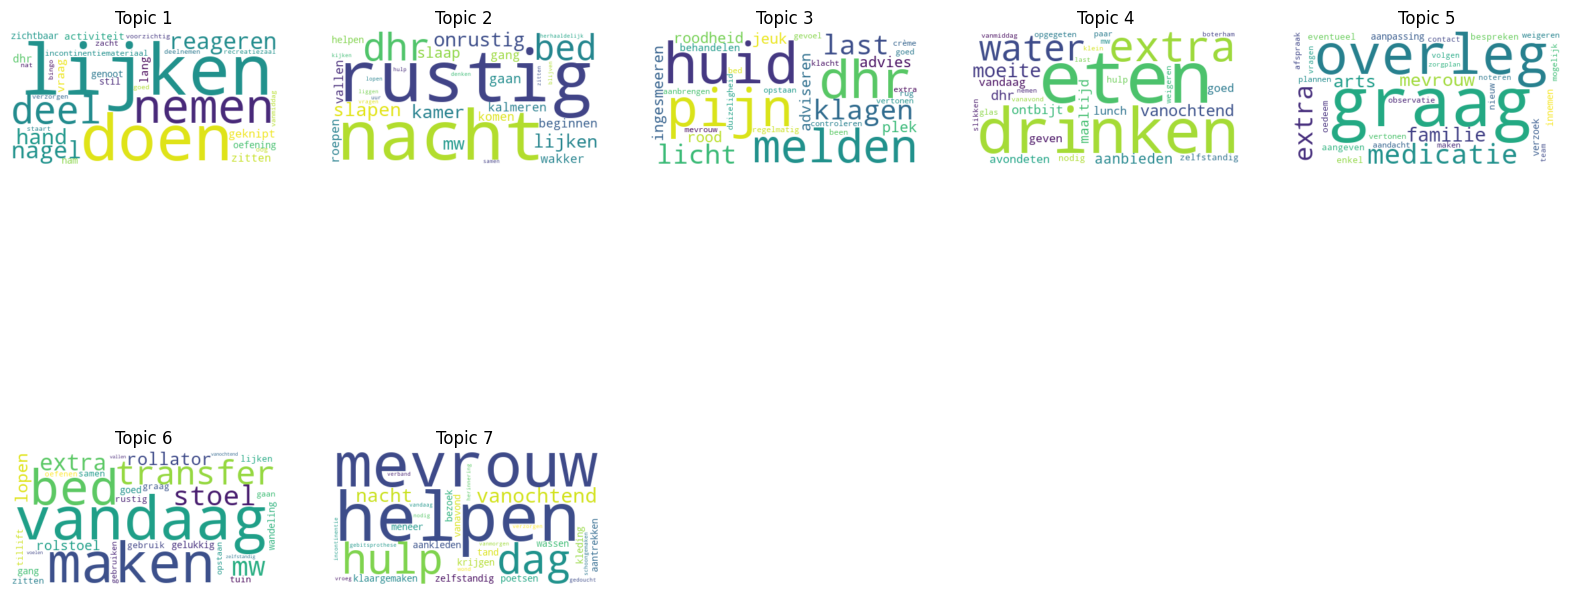

In [26]:
# Function to plot word clouds for topics
def plot_wordclouds(lda_model, dictionary):
    num_topics = lda_model.num_topics
    cols = 5
    rows = (num_topics // cols) + (num_topics % cols > 0)  # Berekent het aantal rijen

    plt.figure(figsize=(20, 10))  # Aanpassen van de breedte en hoogte van de plot
    for idx in range(num_topics):
        plt.subplot(rows, cols, idx + 1)
        topic_words = dict(lda_model.show_topic(idx, 30))
        cloud = WordCloud(background_color='white').generate_from_frequencies(topic_words)
        plt.imshow(cloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('Topic ' + str(idx+1))

    plt.show()

# Plot topics
plot_wordclouds(lda_model, dictionary)

In [27]:
# Visualize topics with pyLDAvis
lda_display = gensimvis.prepare(lda_model, corpus_train, dictionary, sort_topics=False)
pyLDAvis.display(lda_display)

In [28]:
# Function to calculate topic distributions
def get_topic_distributions(lda_model, corpus):
    topic_distributions = []

    for doc_bow in corpus:
        doc_topics = lda_model.get_document_topics(doc_bow, minimum_probability=0)
        topic_distribution = {f'topic_{i}': 0 for i in range(num_topics)}
        for topic, prob in doc_topics:
            topic_distribution[f'topic_{topic}'] = prob
        topic_distributions.append(topic_distribution)

    return topic_distributions


In [29]:
# Calculate topic distributions for all documents
train_topic_dists = get_topic_distributions(lda_model, corpus_train)
test_topic_dists = get_topic_distributions(lda_model, corpus_test)
valid_topic_dists = get_topic_distributions(lda_model, corpus_valid)

In [30]:
# Add topic distributions to DataFrames
for topic in range(num_topics):
    train_df[f'topic_{topic}'] = [dist[f'topic_{topic}'] for dist in train_topic_dists]
    test_df[f'topic_{topic}'] = [dist[f'topic_{topic}'] for dist in test_topic_dists]
    valid_df[f'topic_{topic}'] = [dist[f'topic_{topic}'] for dist in valid_topic_dists]

In [33]:
print(train_df.filter(like='topic_').iloc[test_row])
print(train_df['text'].iloc[test_row])

topic_0    0.250299
topic_1    0.423075
topic_2    0.007525
topic_3    0.007534
topic_4    0.007524
topic_5    0.296507
topic_6    0.007535
Name: 5608, dtype: float32
Mw zat stil aan tafel, staarde voor zich uit en negeerde de vraag of ze koffie wilde. Kwam traag in beweging en mompelde dat ze niet wist wie ze was. Mw naar haar kamer gebracht en rustig bezigheid geboden.


## Word embeddings

In [34]:
# Prepare text data for word embeddings
train_texts = [doc.split() for doc in train_df['text_clean']]  # Splits in tokens
# Train Word2Vec-model
word2vec_model = Word2Vec(sentences=train_texts, vector_size=50, window=5, min_count=1, workers=4)

word2vec_model_path = '../../models/agitation/word2vec_model'
word2vec_model.save(word2vec_model_path)
print(f"Word2Vec-model opgeslagen in: {word2vec_model_path}")

Word2Vec-model opgeslagen in: ../../models/agitation/word2vec_model


In [35]:
# Function to calculate document embeddings
def calculate_document_embedding(text, model):
    embeddings = [model.wv[word] for word in text.split() if word in model.wv]

    if not embeddings:
        return pd.Series(np.zeros(model.vector_size))

    mean_embedding = np.mean(embeddings, axis=0)
    return pd.Series(mean_embedding)

In [36]:
# Calculate document embeddings and add to DataFrames
embedding_columns = [f'embedding_{i}' for i in range(word2vec_model.vector_size)]
train_df[embedding_columns] = train_df['text_clean'].apply(lambda x: calculate_document_embedding(x, word2vec_model))

test_df[embedding_columns] = test_df['text_clean'].apply(lambda x: calculate_document_embedding(x, word2vec_model))
valid_df[embedding_columns] = valid_df['text_clean'].apply(lambda x: calculate_document_embedding(x, word2vec_model))


In [37]:
# Example usage of the trained model
word_embedding = word2vec_model.wv['moeder']
print(word_embedding)

[-0.13312416  0.38298124 -0.10138518  0.24800733 -0.86574554 -0.26218677
  1.089818    1.3400089  -0.8159233   1.446077   -0.35247645 -1.6323453
 -0.3979218   0.2821397  -0.2978004   0.9819527   0.67193234 -0.76803976
 -1.1661949  -1.0489321  -1.0636344   0.61162835  0.90891355 -1.8542185
  0.17780784  0.2152914  -0.33661214  0.21074    -0.9481712   0.07972053
  0.43565705  1.0476676   0.67892575  0.17890155 -0.27996832  1.1076728
  0.07195679  1.0222055   0.6384892  -1.5093734   0.17984542  0.2647851
 -1.1621153  -0.9013661   0.9217586  -0.6678913  -0.73850906 -0.61430824
 -0.2917865   1.0835992 ]


In [44]:
# Find words most similar to 'toilet'
similar_words = word2vec_model.wv.most_similar('paracetamol', topn=10)

for word, similarity in similar_words:
    print(f"Word: {word}, Similarity: {similarity}")


Word: klacht, Similarity: 0.9570242166519165
Word: hartslag, Similarity: 0.9516492486000061
Word: meten, Similarity: 0.9470892548561096
Word: bloeddruk, Similarity: 0.9377259016036987
Word: zuurstofgehalte, Similarity: 0.9368992447853088
Word: temperatuur, Similarity: 0.935186505317688
Word: saturatie, Similarity: 0.9279710054397583
Word: laag, Similarity: 0.9239971041679382
Word: zuurstof, Similarity: 0.9208083152770996
Word: waarde, Similarity: 0.9207159280776978


In [46]:
# Save DataFrames
train_df.to_csv(setup.get_file_path('data/df_agitation_train.csv'), index=False)
test_df.to_csv(setup.get_file_path('data/df_agitation_test.csv'), index=False)
valid_df.to_csv(setup.get_file_path('data/df_agitation_valid.csv'), index=False)

In [47]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25864 entries, 12829 to 31626
Data columns (total 60 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          25864 non-null  object 
 1   label         25864 non-null  int64  
 2   text_clean    25864 non-null  object 
 3   topic_0       25864 non-null  float32
 4   topic_1       25864 non-null  float32
 5   topic_2       25864 non-null  float32
 6   topic_3       25864 non-null  float32
 7   topic_4       25864 non-null  float32
 8   topic_5       25864 non-null  float32
 9   topic_6       25864 non-null  float32
 10  embedding_0   25864 non-null  float32
 11  embedding_1   25864 non-null  float32
 12  embedding_2   25864 non-null  float32
 13  embedding_3   25864 non-null  float32
 14  embedding_4   25864 non-null  float32
 15  embedding_5   25864 non-null  float32
 16  embedding_6   25864 non-null  float32
 17  embedding_7   25864 non-null  float32
 18  embedding_8   25864 non-nul